<div style="text-align:center; padding:18px 0 6px 0"></div>

<div style="text-align:center; color:#8b949e; font-size:12px; padding-bottom:8px">Copyright © QPerfect &middot; Released under the MIT License &middot; <a href="https://qperfect.io">qperfect.io</a></div>

---

# QUBO mappings — from routing to a quantum-ready Hamiltonian

QAOA and most other gate-model quantum optimisation algorithms expect
their problem encoded as a **Hamiltonian** built from Pauli `Z` operators.
The canonical pipeline is:

1. **Combinatorial problem** (TSP, VRP, …)
2. **QUBO** — Quadratic Unconstrained Binary Optimisation,
   $\min_{x \in \{0,1\}^n} x^\mathsf{T} Q x + c$
3. **Ising Hamiltonian** $H = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j + c'$
   via the substitution $x_i = (1 - z_i)/2$ with $z_i \in \{-1, +1\}$
4. **Quantum circuit** — QAOA prepares a state with low ⟨H⟩, measurements
   sample bitstrings that decode back to candidate solutions.

This notebook walks layer by layer. We show the math inline where it's
short and instructive (the QUBO → Ising substitution; how MIMIQ
`Hamiltonian` objects are built from individual Pauli terms) and delegate
to the encoders shipped in `strasbourg_markets_demo.{tsp,vrp}` for the
heavier lifting (the Lucas-2014 TSP and full one-hot VRP encodings,
which are dozens of lines of constraint bookkeeping).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

import mimiqcircuits as mc

from strasbourg_markets_demo import strasbourg as s, theme
from strasbourg_markets_demo.qubo import QUBO, bitstring_to_array, plot_q_matrix
from strasbourg_markets_demo.tsp import TSPInstance, brute_force as tsp_bf, to_qubo as tsp_to_qubo, tour_from_bitstring
from strasbourg_markets_demo.vrp import VRPInstance, m_vrp_brute_force, to_qubo as vrp_to_qubo, routes_from_bitstring

theme.apply()


## 1. What is a QUBO?

A **QUBO** is the canonical optimisation problem on `n` binary variables:

$$\min_{x \in \{0,1\}^n}\; x^\mathsf{T} Q x \;+\; c$$

`Q` is an `n × n` matrix, `c` a constant offset (irrelevant to the argmin
but kept around for absolute-energy reporting). Hard constraints are
encoded as **squared penalty terms**: `P · (Σ_k a_k x_k − b)²` is added to
the objective with `P` chosen large enough that violating the constraint
costs more than any feasible improvement.

A 3-variable toy:  minimise $x_1 + 2 x_2 + 3 x_3 + 4 x_1 x_2 - 5 x_2 x_3$.

We use the `QUBO` container (`strasbourg_markets_demo.qubo.QUBO`) — but
note its convention: `Q` is stored *symmetrically*, so `x @ Q @ x` counts
each off-diagonal pair twice. `add_quadratic(i, j, c)` splits the
coefficient correctly between `Q[i,j]` and `Q[j,i]`.


In [2]:
n = 3
toy = QUBO(Q=np.zeros((n, n)))
toy.add_linear(0, 1.0); toy.add_linear(1, 2.0); toy.add_linear(2, 3.0)
toy.add_quadratic(0, 1, 4.0); toy.add_quadratic(1, 2, -5.0)

# Energy of every bitstring — `QUBO.evaluate` is just `x @ Q @ x + offset`.
print(f"{'x':10s}  {'energy':>8s}   matches manual formula?")
print("-" * 50)
Q = toy.Q
for x in itertools.product([0, 1], repeat=n):
    e_qubo   = toy.evaluate(x)
    e_manual = (1*x[0] + 2*x[1] + 3*x[2]
                + 4*x[0]*x[1] - 5*x[1]*x[2])
    print(f"{str(x):10s}  {e_qubo:8.3f}   {abs(e_qubo - e_manual) < 1e-9}")


x             energy   matches manual formula?
--------------------------------------------------
(0, 0, 0)      0.000   True
(0, 0, 1)      3.000   True
(0, 1, 0)      2.000   True
(0, 1, 1)      0.000   True
(1, 0, 0)      1.000   True
(1, 0, 1)      4.000   True
(1, 1, 0)      7.000   True
(1, 1, 1)      5.000   True


## 2. QUBO → Ising

Substituting $x_i = (1 - z_i)/2$ with $z_i \in \{-1, +1\}$ converts the
QUBO into an **Ising Hamiltonian**:

$$H(z) = \sum_i h_i\, z_i \;+\; \sum_{i<j} J_{ij}\, z_i z_j \;+\; c'$$

The substitution into $\sum_{i,j} Q_{ij} x_i x_j$ expands and recombines
into linear, quadratic, and constant parts. For symmetric `Q` the
coefficients are:

- $h_i = -\frac{1}{2} \sum_j Q_{ij}$   (linear)
- $J_{ij} = \frac{1}{2} Q_{ij}$ for $i < j$   (quadratic)
- $c' = c + \frac{1}{4}\bigl(\sum_{ij} Q_{ij} + \mathrm{tr}(Q)\bigr)$   (constant)

The mapping is a bijection: every classical bitstring $x$ corresponds to a
unique vector $z$ with $z_i = 1 - 2 x_i$, and the Ising energy of $z$
equals the QUBO energy of $x$.


In [3]:
# Manual derivation — compute h, J, c' directly from Q to make the formulas
# concrete. (`QUBO.to_ising()` is exactly this, vectorised.)
Q_sym = (toy.Q + toy.Q.T) / 2.0
h_manual = -0.5 * Q_sym.sum(axis=1)
J_manual = 0.5 * np.triu(Q_sym, k=1)
c_manual = (Q_sym.sum() + np.trace(Q_sym)) / 4.0 + toy.offset

print(f"manual:  h = {h_manual}")
print(f"manual:  J (upper) =\n{J_manual}")
print(f"manual:  c' = {c_manual:.3f}")

# Verify against the helper:
h, J, c_total = toy.to_ising()
print()
print(f"to_ising matches manual: "
      f"h={np.allclose(h, h_manual)}, J={np.allclose(J, J_manual)}, c'={np.isclose(c_total, c_manual)}")


manual:  h = [-1.5  -0.75 -0.25]
manual:  J (upper) =
[[ 0.    1.    0.  ]
 [ 0.    0.   -1.25]
 [ 0.    0.    0.  ]]
manual:  c' = 2.750

to_ising matches manual: h=True, J=True, c'=True


In [4]:
# Energy verification — every bitstring's QUBO and Ising energies must agree.
print(f"{'x':10s}  {'QUBO E':>8s}  {'Ising E':>8s}   match")
print("-" * 42)
for x in itertools.product([0, 1], repeat=n):
    z = 1 - 2 * np.array(x)
    e_qubo = toy.evaluate(x)
    e_ising = float(h @ z) + float(sum(J[i, j] * z[i] * z[j]
                                       for i in range(n) for j in range(i + 1, n))) + c_total
    print(f"{str(x):10s}  {e_qubo:8.3f}  {e_ising:8.3f}   {abs(e_qubo - e_ising) < 1e-9}")


x             QUBO E   Ising E   match
------------------------------------------
(0, 0, 0)      0.000     0.000   True
(0, 0, 1)      3.000     3.000   True
(0, 1, 0)      2.000     2.000   True
(0, 1, 1)      0.000     0.000   True
(1, 0, 0)      1.000     1.000   True
(1, 0, 1)      4.000     4.000   True
(1, 1, 0)      7.000     7.000   True
(1, 1, 1)      5.000     5.000   True


## 3. Qubits ↔ variables

The Ising form is the **diagonal Hamiltonian** of a multi-qubit operator:

$$\hat H = \sum_i h_i\, Z_i \;+\; \sum_{i<j} J_{ij}\, Z_i Z_j \;+\; c' \mathbb{1}$$

where `Z_i` is the Pauli-Z operator on qubit `i`. Each binary variable `x_i`
corresponds to qubit `i`:

| Ising | Qubit | Decoding |
|-------|-------|----------|
| `z_i = +1` | `\|0⟩` | `x_i = 0` |
| `z_i = -1` | `\|1⟩` | `x_i = 1` |

The QUBO ground-state energy = lowest eigenvalue of $\hat H$. QAOA sets up
a parameterised circuit whose final state has a small expectation
$\langle \hat H \rangle$; measurement in the computational basis returns a
bitstring `x` that decodes to a candidate solution.

### A short MIMIQ-Hamiltonian primer

In `mimiqcircuits`, a Hamiltonian is a sum of weighted Pauli strings,
each acting on a chosen tuple of qubits. You build it incrementally:

```python
H = mc.Hamiltonian()
H.push(coeff, mc.PauliString("Z"),  qubit)         # coeff · Z_q
H.push(coeff, mc.PauliString("ZZ"), q1, q2)        # coeff · Z_{q1} Z_{q2}
H.push(coeff, mc.PauliString("XY"), q1, q2)        # coeff · X_{q1} Y_{q2}
```

`PauliString("ZZ")` is just a 2-character spec — any combination of
`I`, `X`, `Y`, `Z` is allowed. The Hamiltonian object supports `len(H)`
and `H[k]` for inspection.

For QAOA two methods on `Circuit` consume a Hamiltonian directly:

- `circuit.push_suzukitrotter(H, qubits, t=γ, steps=1, order=2)` —
  Trotterised `exp(-i γ H)` (the QAOA cost layer).
- `circuit.push_expval(H, *qubits)` — stores `⟨H⟩` in the z-register
  without explicit measurement (handy for the QAOA objective).

Let's exercise the API on a tiny example before applying it to the toy QUBO:


In [5]:
demo = mc.Hamiltonian()
print(f"empty Hamiltonian: {len(demo)} terms")

demo.push( 2.5, mc.PauliString("Z"),  0)     # 2.5 · Z_0
demo.push(-1.0, mc.PauliString("ZZ"), 0, 1)  # -1 · Z_0 Z_1
demo.push( 0.5, mc.PauliString("XY"), 1, 2)  # 0.5 · X_1 Y_2

print(f"after three pushes: {len(demo)} terms")
for k in range(len(demo)):
    print(f"  term {k}: {demo[k]}")


empty Hamiltonian: 0 terms
after three pushes: 3 terms
  term 0: 2.5 * Z @ q[0]
  term 1: -1.0 * ZZ @ q[0,1]
  term 2: 0.5 * XY @ q[1,2]


### Building the toy QUBO's Hamiltonian by hand

Now the small QUBO above. We already have its `(h, J)` from §2; one loop
each for the linear `Z` terms and the quadratic `ZZ` terms produces a
`mc.Hamiltonian`. The `QUBO.to_hamiltonian()` helper does exactly this
internally — handy when the QUBO has thousands of terms — but on a
3-variable toy it's clearest to spell it out.


In [6]:
# Manual construction
H_manual = mc.Hamiltonian()
for i in range(n):
    if abs(h[i]) > 1e-12:
        H_manual.push(float(h[i]), mc.PauliString("Z"), i)
for i in range(n):
    for j in range(i + 1, n):
        if abs(J[i, j]) > 1e-12:
            H_manual.push(float(J[i, j]), mc.PauliString("ZZ"), i, j)
print(f"manual build: {len(H_manual)} weighted Pauli terms")
for k in range(len(H_manual)):
    print(f"  {H_manual[k]}")

# Same thing via the helper
print()
H_helper = toy.to_hamiltonian()
print(f"qubo.to_hamiltonian(): {len(H_helper)} terms — same count: {len(H_helper) == len(H_manual)}")


manual build: 5 weighted Pauli terms
  -1.5 * Z @ q[0]
  -0.75 * Z @ q[1]
  -0.25 * Z @ q[2]
  1.0 * ZZ @ q[0,1]
  -1.25 * ZZ @ q[1,2]

qubo.to_hamiltonian(): 5 terms — same count: True


## 4. TSP → QUBO  (Lucas-2014 one-hot encoding)

Variables: $x_{i,t}$ for city `i` and tour position `t`. Linear index
`q = i · n + t`. **n² qubits.**

Cost (closed tour):
$$\sum_{t=0}^{n-1} \sum_{i \neq j} d(i, j)\, x_{i,t}\, x_{j,(t+1) \bmod n}$$

Constraints, added as squared penalties with weight `P`:
- Each city visited exactly once: $\sum_t x_{i,t} = 1$
- Each position used exactly once: $\sum_i x_{i,t} = 1$

`P` defaults to `4 · max d` (Lucas-2014 §7.1) — large enough that any
infeasible bitstring has higher energy than any feasible one.

The encoder lives in `tsp.to_qubo`. The cost-edge contribution alone is
just a few lines — illustrative even though the full encoder also handles
the row/column penalties:

```python
# Excerpt from tsp.to_qubo's cost loop:
for t in range(n):
    t_next = (t + 1) % n               # closed tour
    for i in range(n):
        for j in range(n):
            if i == j: continue
            q1 = i * n + t              # qubit for "city i at position t"
            q2 = j * n + t_next         # qubit for "city j at next position"
            Q[q1, q2] += d(i, j) / 2    # symmetric storage
            Q[q2, q1] += d(i, j) / 2
```

Below: a 4-Strasbourg-market subset → 16 qubits.


In [7]:
markets4 = s.tsp_five()[:4]
inst4 = TSPInstance.from_coords(
    coords=s.coords_array(markets4),
    names=[m.name for m in markets4],
    metric="haversine",
)
qubo_tsp = tsp_to_qubo(inst4)
print(f"cities  = {inst4.n}")
print(f"qubits  = {qubo_tsp.n_qubits}")
print(f"penalty = {(4.0 * inst4.distances.max()):.1f} m")
print(f"offset  = {qubo_tsp.offset:.1f}")
print()
print("first 5 qubit labels (city, position):")
for q, lab in enumerate(qubo_tsp.labels[:5]):
    print(f"  q{q:2d} -> {lab}")


cities  = 4
qubits  = 16
penalty = 1826.5 m
offset  = 14611.7

first 5 qubit labels (city, position):
  q 0 -> ('Place Kléber', 0)
  q 1 -> ('Place Kléber', 1)
  q 2 -> ('Place Kléber', 2)
  q 3 -> ('Place Kléber', 3)
  q 4 -> ('Place Broglie', 0)


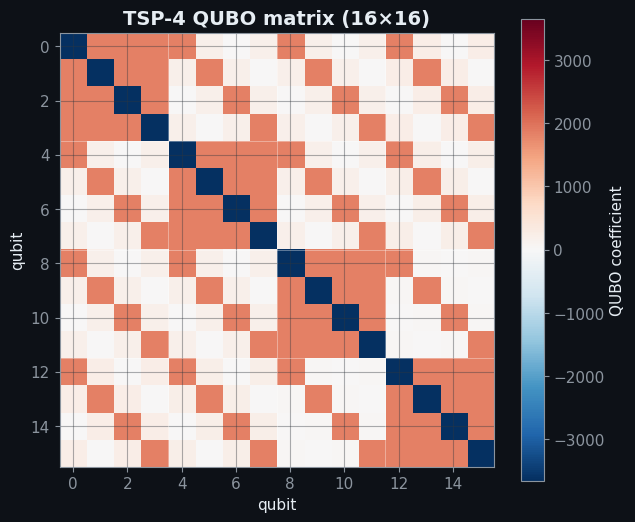

In [8]:
# Visualise the QUBO matrix. Block structure is visible: large diagonal
# block from the constraints, sparse off-block from the tour-edge cost.
plot_q_matrix(qubo_tsp,
              title=f"TSP-{inst4.n} QUBO matrix ({qubo_tsp.n_qubits}×{qubo_tsp.n_qubits})",
              block_size=inst4.n)   # one block per city
plt.show()


In [9]:
# Brute-force verify: among all 2^16 bitstrings, the QUBO argmin (over
# feasible bitstrings) decodes to the same tour the classical solver finds.
opt_tour, opt_len = tsp_bf(inst4)
print(f"classical brute-force: tour={opt_tour.tolist()}  length={opt_len:.1f} m")

best_e = float("inf")
best_tour = None
for bits in itertools.product([0, 1], repeat=qubo_tsp.n_qubits):
    e = qubo_tsp.evaluate(bits)
    if e < best_e:
        decoded = tour_from_bitstring(qubo_tsp, bits, n_cities=inst4.n)
        if decoded is not None:
            best_e = e
            best_tour = decoded
print(f"qubo argmin (feasible): tour={best_tour.tolist()}  energy={best_e:.1f} m")
print(f"matches: {abs(inst4.tour_length(best_tour) - opt_len) < 1e-9}")


classical brute-force: tour=[0, 1, 3, 2]  length=1245.4 m
qubo argmin (feasible): tour=[0, 1, 3, 2]  energy=1245.4 m
matches: True


## 5. VRP → QUBO  (full one-hot encoding)

Variables: $x_{i,t,k}$ where customer `i ∈ 0..n-1`, position `t ∈ 0..L-1`,
vehicle `k ∈ 0..K-1`. **n · L · K qubits**, with `L = ⌈n/K⌉` for the
m-VRP defaults.

Cost (per vehicle, with a depot-return correction so partial routes are
priced exactly):

$$\sum_k \Bigl[\sum_i d(0, i)\, x_{i,0,k}
+ \sum_t \sum_{i,j} d(i,j)\, x_{i,t,k} x_{j,t+1,k}
+ \sum_t \sum_i d(i,0)\, x_{i,t,k}\bigl(1 - \sum_j x_{j,t+1,k}\bigr)
+ \sum_i d(i,0)\, x_{i,L-1,k}\Bigr]$$

Constraints: each customer in exactly one slot; each `(t, k)` slot has at
most one customer.

The qubit-index helper makes the bookkeeping concrete:

```python
# Excerpt from vrp.to_qubo:
def q_idx(i, t, k):                # customer × position × vehicle
    return i * L * K + t * K + k

# Depot → first leg of every vehicle's route
for k in range(K):
    for i in range(n):
        Q[q_idx(i, 0, k), q_idx(i, 0, k)] += d(0, i+1)
```

The full encoder (`vrp.to_qubo`) layers on the consecutive-position cost,
the depot-return correction, and the two penalty groups.

Below: 3 customers, 2 vehicles → 12 qubits.


In [10]:
inst_vrp = VRPInstance.random(n_customers=3, n_vehicles=2, seed=2024)
qubo_vrp = vrp_to_qubo(inst_vrp)
print(f"customers = {inst_vrp.n_customers}")
print(f"vehicles  = {inst_vrp.n_vehicles}")
print(f"L (positions per vehicle) = {int(inst_vrp.capacity)}")
print(f"qubits    = {qubo_vrp.n_qubits}")
print(f"first 6 qubit labels (customer, position, vehicle):")
for q, lab in enumerate(qubo_vrp.labels[:6]):
    print(f"  q{q:2d} -> {lab}")


customers = 3
vehicles  = 2
L (positions per vehicle) = 2
qubits    = 12
first 6 qubit labels (customer, position, vehicle):
  q 0 -> ('1', 0, 0)
  q 1 -> ('1', 0, 1)
  q 2 -> ('1', 1, 0)
  q 3 -> ('1', 1, 1)
  q 4 -> ('2', 0, 0)
  q 5 -> ('2', 0, 1)


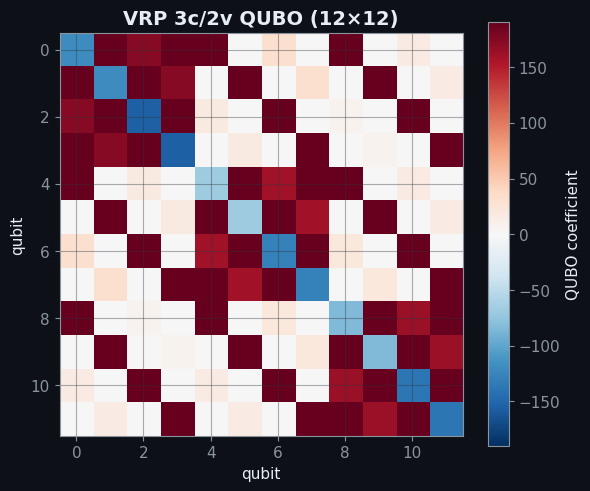

In [11]:
plot_q_matrix(qubo_vrp, figsize=(6.5, 5.5),
              title=f"VRP {inst_vrp.n_customers}c/{inst_vrp.n_vehicles}v QUBO "
                    f"({qubo_vrp.n_qubits}×{qubo_vrp.n_qubits})")
plt.show()


In [12]:
# Verify: brute-force argmin matches the classical m-VRP solver.
opt_routes, opt_total = m_vrp_brute_force(inst_vrp)
print(f"classical optimum: routes={opt_routes}  total={opt_total:.4f}")

n, K = inst_vrp.n_customers, inst_vrp.n_vehicles
L = qubo_vrp.n_qubits // (n * K)

best_e = float("inf")
best_routes = None
for bits in itertools.product([0, 1], repeat=qubo_vrp.n_qubits):
    e = qubo_vrp.evaluate(bits)
    if e < best_e:
        decoded = routes_from_bitstring(qubo_vrp, bits, n_customers=n,
                                        n_vehicles=K, n_positions=L)
        if decoded is not None:
            best_e = e
            best_routes = decoded
decoded_total = inst_vrp.total_distance(best_routes)
print(f"qubo argmin: routes={best_routes}  decoded total={decoded_total:.4f}")
print(f"matches: {abs(decoded_total - opt_total) < 1e-9}")


classical optimum: routes=[[1, 3], [2]]  total=276.6560
qubo argmin: routes=[[2], [3, 1]]  decoded total=276.6560
matches: True


## 6. Resource estimation — qubits vs problem size

How does the qubit count scale?

- **TSP**: `n²` qubits (Lucas-2014 one-hot)
- **VRP**: `n · L · K` qubits with `L = ⌈n/K⌉` (full one-hot)

For reference, three regimes:

- **Statevector simulation**: stores `2^n` complex amplitudes. Practical
  ceiling around `n ≈ 30` (16 GB of RAM); hard wall around `n ≈ 50`.
- **MPS simulation** (MIMIQ default): polynomial in `n`, scales with
  bond dimension. Comfortably handles QAOA at hundreds of qubits.
- **Real QPUs**: IBM Heron 133 qubits, Google Willow 105 qubits, IonQ Forte
  36 algorithmic qubits.


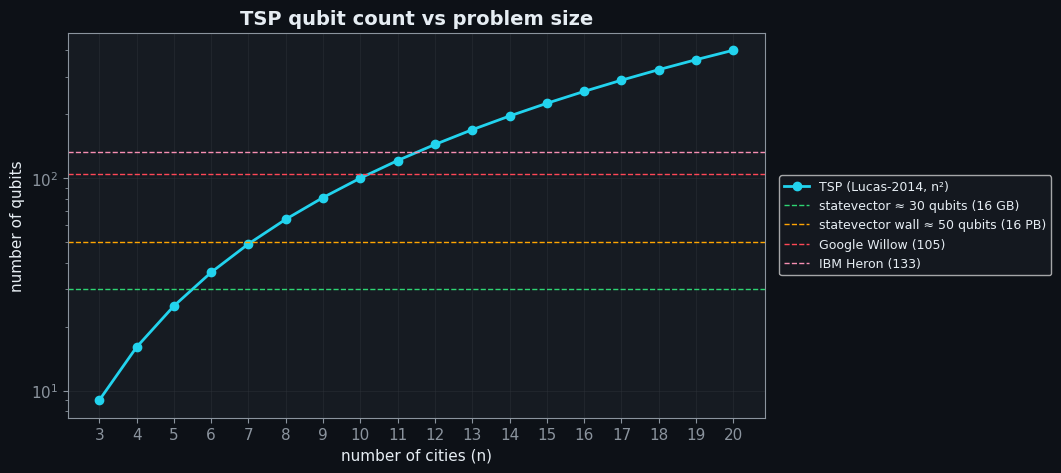

  n    qubits  note
  3         9  statevector OK
  4        16  statevector OK
  5        25  statevector OK
  6        36  MPS territory
  7        49  MPS territory
 10       100  MPS territory
 12       144  MPS territory
 15       225  frontier QPU
 20       400  frontier QPU


In [13]:
# TSP — qubits as a function of n
ns = np.arange(3, 21)
tsp_qubits = ns ** 2

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ns, tsp_qubits, "o-", color=theme.PALETTE["cyan"], lw=2, label="TSP (Lucas-2014, n²)")
ax.axhline(30, color=theme.PALETTE["green"], ls="--", lw=1, label="statevector ≈ 30 qubits (16 GB)")
ax.axhline(50, color=theme.PALETTE["yellow"], ls="--", lw=1, label="statevector wall ≈ 50 qubits (16 PB)")
ax.axhline(105, color=theme.PALETTE["red"], ls="--", lw=1, label="Google Willow (105)")
ax.axhline(133, color=theme.PALETTE["pink"], ls="--", lw=1, label="IBM Heron (133)")
ax.set_xlabel("number of cities (n)")
ax.set_ylabel("number of qubits")
ax.set_title("TSP qubit count vs problem size")
ax.set_yscale("log"); ax.set_xticks(ns)
s.place_legend_outside(ax)
plt.show()

print(f"{'n':>3s}  {'qubits':>8s}  {'note':s}")
for n in [3, 4, 5, 6, 7, 10, 12, 15, 20]:
    note = "statevector OK" if n*n <= 30 else "MPS territory" if n*n <= 200 else "frontier QPU"
    print(f"{n:3d}  {n*n:8d}  {note}")


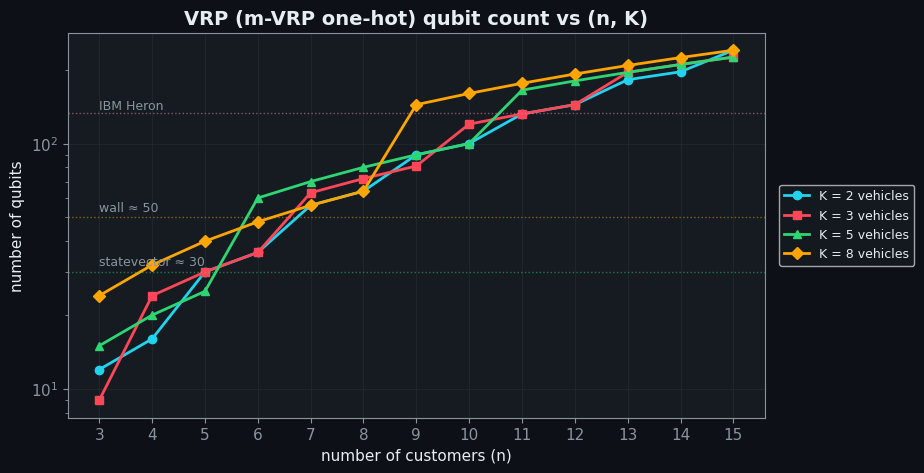

In [14]:
# VRP — qubits as a function of (n, K) for the m-VRP encoding (L = ceil(n/K))
fig, ax = plt.subplots(figsize=(9, 5))
ns = np.arange(3, 16)
for K, color, marker in [(2, theme.PALETTE["cyan"], "o"),
                          (3, theme.PALETTE["red"], "s"),
                          (5, theme.PALETTE["green"], "^"),
                          (8, theme.PALETTE["yellow"], "D")]:
    qubits = [n * int(np.ceil(n / K)) * K for n in ns]
    ax.plot(ns, qubits, marker + "-", color=color, lw=2, label=f"K = {K} vehicles")

ax.axhline(30, color=theme.PALETTE["green"], ls=":", lw=1, alpha=0.5)
ax.axhline(50, color=theme.PALETTE["yellow"], ls=":", lw=1, alpha=0.5)
ax.axhline(133, color=theme.PALETTE["pink"], ls=":", lw=1, alpha=0.5)
ax.text(3, 32, "statevector ≈ 30", fontsize=9, color=theme.PALETTE["muted"])
ax.text(3, 53, "wall ≈ 50",         fontsize=9, color=theme.PALETTE["muted"])
ax.text(3, 138, "IBM Heron",         fontsize=9, color=theme.PALETTE["muted"])
ax.set_xlabel("number of customers (n)")
ax.set_ylabel("number of qubits")
ax.set_title("VRP (m-VRP one-hot) qubit count vs (n, K)")
ax.set_yscale("log"); ax.set_xticks(ns)
s.place_legend_outside(ax)
plt.show()


In [15]:
# Compact tabular summary for the slide deck.
print(f"{'problem':<22s}  {'qubits':>7s}  {'simulator regime':<22s}")
print("-" * 56)
for label, n_q in [
    ("TSP-3   (3 cities)",         3 * 3),
    ("TSP-4   (4 cities)",         4 * 4),
    ("TSP-5   (Strasbourg)",       5 * 5),
    ("TSP-7   (7 cities)",         7 * 7),
    ("TSP-10  (10 cities)",       10 * 10),
    ("TSP-15  (15 cities)",       15 * 15),
    ("VRP 5/2 (5 cust, 2 veh)",   5 * 3 * 2),
    ("VRP 5/3 (Strasbourg)",      5 * 2 * 3),
    ("VRP 8/3",                   8 * 3 * 3),
    ("VRP 10/3",                 10 * 4 * 3),
    ("VRP 15/3",                 15 * 5 * 3),
]:
    if n_q <= 25:
        regime = "exact statevector"
    elif n_q <= 50:
        regime = "MPS / heavy SV"
    elif n_q <= 200:
        regime = "MPS comfortable"
    else:
        regime = "MPS w/ tuning"
    print(f"{label:<22s}  {n_q:>7d}  {regime:<22s}")


problem                  qubits  simulator regime      
--------------------------------------------------------
TSP-3   (3 cities)            9  exact statevector     
TSP-4   (4 cities)           16  exact statevector     
TSP-5   (Strasbourg)         25  exact statevector     
TSP-7   (7 cities)           49  MPS / heavy SV        
TSP-10  (10 cities)         100  MPS comfortable       
TSP-15  (15 cities)         225  MPS w/ tuning         
VRP 5/2 (5 cust, 2 veh)       30  MPS / heavy SV        
VRP 5/3 (Strasbourg)         30  MPS / heavy SV        
VRP 8/3                      72  MPS comfortable       
VRP 10/3                    120  MPS comfortable       
VRP 15/3                    225  MPS w/ tuning         


## Summary

- A QUBO is `min x^T Q x + c` over binary `x`. Hard constraints become
  squared penalties.
- The Ising form `H = Σ h_i Z_i + Σ J_ij Z_i Z_j + c'` follows from
  `x_i = (1 − z_i) / 2`. Each binary variable becomes one qubit; the
  ground state encodes the QUBO optimum.
- `QUBO.to_hamiltonian()` returns a ready-to-use
  `mimiqcircuits.Hamiltonian` — the cost Hamiltonian in QAOA.
- TSP under Lucas-2014 needs `n²` qubits; VRP under full one-hot needs
  `n · ⌈n/K⌉ · K` qubits — both verified against classical brute force on
  small instances.
- For the Strasbourg demo: TSP-5 = **25 qubits** (small for MPS), VRP-5/3
  = **30 qubits**. Scaling to a few-dozen-customer instance puts us
  comfortably in the regime where statevector simulation breaks but MIMIQ
  MPS still delivers exact-up-to-truncation answers.

For a deeper dive into encoding choices (XY-mixers, alternative
formulations), see `notes/12-mapping-tsp-vrp-to-qaoa.md`.



---

<div style="text-align:center; padding:18px 0 6px 0"></div>

<div style="text-align:center; color:#8b949e; font-size:12px; padding-bottom:8px">Copyright © QPerfect &middot; Released under the MIT License &middot; <a href="https://qperfect.io">qperfect.io</a></div>